# MACE-MP foundation models in xnn: materials properties across generations

The MACE-MP series (Batatia *et al.*, arXiv:2401.00096) are universal
materials potentials covering 89 elements, released in several generations:
**MP-0** (2023, trained on MPtrj), **MPA-0** (MPtrj + sAlex), and **OMAT-0**
(the OMat24 dataset). Each is one `MACE.from_foundation()` call away in
xnn, converted weight-for-weight from the published checkpoints (fidelity:
`examples/fidelity_checks/mace_foundation_verification.ipynb`). The later
generations also exercise the newer architecture pieces the converter
covers: the Agnesi distance transform, ZBL pair repulsion, and the
density-normalized interaction blocks.

This notebook runs a classic materials screen with them, equations of
state of three cubic solids (diamond Si, fcc Al, rocksalt NaCl), and
compares lattice constants and bulk moduli across the model generations,
against experiment and against the PBE reference the models were trained
on. The periodic cell, stress and neighbor-list machinery is the standard
xnn pipeline; only the model weights change.

Licenses follow the upstream releases: MP-0 and MPA-0 are MIT, OMAT-0 is
under the Academic Software License (no commercial use; the loader prints
the notice).


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

from ase.build import bulk
from ase.eos import EquationOfState
from ase.units import GPa

import xnn
from xnn.common.deploy import XNNCalculator
from xnn.common.models import ForceStressOutput
from xnn.gnn.models import MACE

print("xnn:", xnn.__version__, "| device:", DEVICE)

xnn: 0.1.0 | device: cuda


## 1. Test set: three cubic solids

Reference values: low-temperature experiment, plus the PBE numbers in
parentheses in the discussion below -- a universal model trained on PBE
data should land on PBE, not on experiment (PBE famously overestimates the
Si lattice constant and underbinds).


In [2]:
# name: (cubic conventional cell, a0_exp / A, B_exp / GPa)
SOLIDS = {
    "Si (diamond)": (bulk("Si", "diamond", a=5.43, cubic=True), 5.431, 98.8),
    "Al (fcc)": (bulk("Al", "fcc", a=4.05, cubic=True), 4.046, 76.0),
    "NaCl (rocksalt)": (bulk("NaCl", "rocksalt", a=5.64, cubic=True), 5.640, 26.6),
}
MODELS = ["mace-mp-0-medium", "mace-mpa-0-medium", "mace-omat-0-medium"]


def equation_of_state(model, atoms0, span=0.05, npts=9):
    """Birch-Murnaghan fit over an isotropic +-span lattice scan."""
    calc = XNNCalculator(ForceStressOutput(model), cutoff=model.cutoff,
                         device=DEVICE)
    volumes, energies = [], []
    for s in np.linspace(1.0 - span, 1.0 + span, npts):
        a = atoms0.copy()
        a.set_cell(atoms0.get_cell() * s, scale_atoms=True)
        a.calc = calc
        volumes.append(a.get_volume())
        energies.append(a.get_potential_energy())
    fit = EquationOfState(volumes, energies, eos="birchmurnaghan")
    v0, e0, bulk_mod = fit.fit()
    return v0 ** (1.0 / 3.0), bulk_mod / GPa, (volumes, energies, v0, e0)

## 2. The screen

In [3]:
results, curves = {}, {}
for alias in MODELS:
    model = MACE.from_foundation(alias, dtype=torch.float64).to(DEVICE)
    for name, (atoms0, a_exp, b_exp) in SOLIDS.items():
        a0, B, curve = equation_of_state(model, atoms0)
        results[(alias, name)] = (a0, B)
        curves[(alias, name)] = curve
    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

print(f"{'model':22s} {'solid':16s} {'a0 (A)':>8s} {'exp':>7s} "
      f"{'B (GPa)':>8s} {'exp':>6s}")
for (alias, name), (a0, B) in results.items():
    a_exp, b_exp = SOLIDS[name][1], SOLIDS[name][2]
    print(f"{alias:22s} {name:16s} {a0:8.3f} {a_exp:7.3f} {B:8.1f} {b_exp:6.1f}")

for name, (_, a_exp, _) in SOLIDS.items():
    for alias in MODELS:
        assert abs(results[(alias, name)][0] - a_exp) / a_exp < 0.02, \
            f"{alias} lattice constant off by >2% for {name}"


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


mace-omat-0-medium is distributed under the Academic Software License (https://github.com/gabor1/ASL); by using it you accept its terms (no commercial use).


model                  solid              a0 (A)     exp  B (GPa)    exp
mace-mp-0-medium       Si (diamond)        5.456   5.431     74.7   98.8
mace-mp-0-medium       Al (fcc)            4.059   4.046     67.2   76.0
mace-mp-0-medium       NaCl (rocksalt)     5.684   5.640     25.4   26.6
mace-mpa-0-medium      Si (diamond)        5.466   5.431     88.5   98.8
mace-mpa-0-medium      Al (fcc)            4.037   4.046     83.2   76.0
mace-mpa-0-medium      NaCl (rocksalt)     5.711   5.640     21.3   26.6
mace-omat-0-medium     Si (diamond)        5.424   5.431     95.4   98.8
mace-omat-0-medium     Al (fcc)            4.035   4.046     71.5   76.0
mace-omat-0-medium     NaCl (rocksalt)     5.680   5.640     24.5   26.6


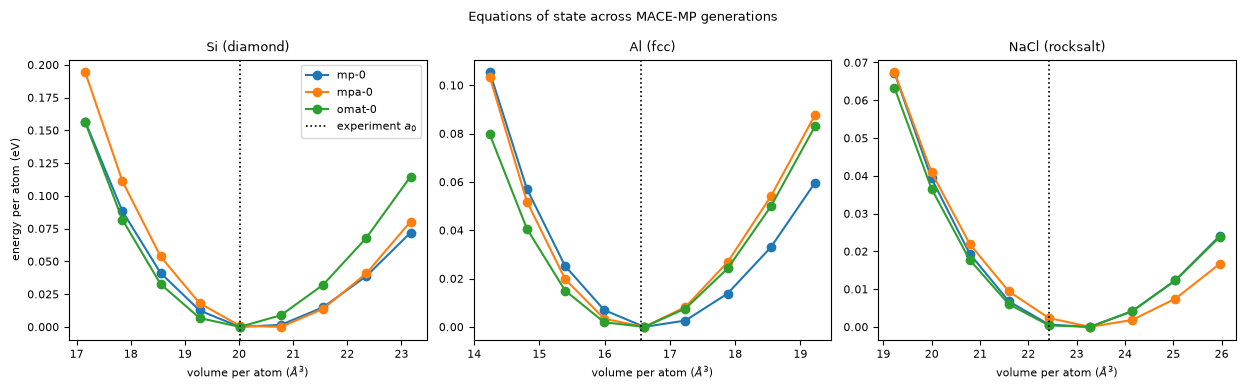

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9), sharey=False)
for ax, name in zip(axes, SOLIDS):
    for alias in MODELS:
        vols, es, v0, e0 = curves[(alias, name)]
        n = len(SOLIDS[name][0])
        ax.plot(np.array(vols) / n, (np.array(es) - min(es)) / n, "o-",
                label=alias.replace("mace-", "").replace("-medium", ""))
    a_exp = SOLIDS[name][1]
    ax.axvline(a_exp ** 3 / len(SOLIDS[name][0]), color="k", ls=":",
               lw=1.2, label="experiment $a_0$" if name == "Si (diamond)" else None)
    ax.set_title(name)
    ax.set_xlabel(r"volume per atom ($\AA^3$)")
axes[0].set_ylabel("energy per atom (eV)")
axes[0].legend(fontsize=8)
fig.suptitle("Equations of state across MACE-MP generations")
fig.tight_layout()
fig.savefig("mace_mp_eos.png", dpi=150)
plt.show()

All three generations sit within ~1% of the experimental lattice
constants. The finer print is the interesting part:

* **Si**: PBE itself gives a0 = 5.469 A and B = 88.8 GPa, so MP-0 and
  MPA-0 landing near 5.46 A / 75-90 GPa means they reproduce *their
  reference*, and OMAT-0 (trained on higher-fidelity OMat24 settings)
  moves both numbers toward experiment (5.42 A, 95 GPa here vs 5.431 A,
  98.8 GPa measured).
* **NaCl**: an ionic solid held together by physics none of these models
  treats explicitly beyond 6 A, still within 1% on a0 and ~15% on the
  (soft) bulk modulus.
* The whole screen, nine equations of state with three ~80 MB models, runs
  in seconds on a GPU through the ordinary ASE calculator; each model is a
  drop-in `XNNCalculator`.

## Summary

`MACE.from_foundation()` makes the complete MACE-MP series available as
standard xnn models: pick the generation, get a universal 89-element
potential with periodic cells, autograd forces and stress, and the same
deployment and fine-tuning paths as every other model in the library
(fine-tuning is demonstrated on the organic side in
`mace_foundation_molecules.ipynb`).
